# **AN2DL Second Challenge**
> ## ***Ibuprofen*** team

## 🌐 **Google Drive Connection**

In [1]:
from google.colab import drive
drive.mount("/gdrive")

working_dir = "/gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge/v1"
input_dir = "/gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge"

%cd $working_dir

print(f"Working at folder: {working_dir}")
print(f"Input at folder: {input_dir}")

Mounted at /gdrive
/gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge/v1
Working at folder: /gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge/v1
Input at folder: /gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge


---
## ⚙️ **Libraries Import**

In [2]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO
import shutil
from tqdm import tqdm  # Progress bar

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


---
## ⏳ **Data unzip in local runtime**

In [25]:
dataset_src_dir = f"{input_dir}/grumpy-doctogres"

EXPECTED_TRAIN_DATA_DIR   = "train_data_crops_crop224_ov56"
EXPECTED_TRAIN_LABELS_CSV = "train_labels_crops_crop224_ov56.csv"
EXPECTED_TEST_DATA_DIR    = "test_data"

TRAIN_ZIP_NAME = f"{EXPECTED_TRAIN_DATA_DIR}.zip"
TEST_ZIP_NAME  = f"{EXPECTED_TEST_DATA_DIR}.zip"


# --- 1. Define Local Destination Base Path (Colab Runtime) ---
# This is the root directory where all unzipped data will reside.
local_base = f"/content/grumpy-doctogres"

# --- 2. Define Local Paths to the extracted data ---
# These paths point to the data within the locally unzipped directory.
trainval_data_dir    = f"{local_base}/{EXPECTED_TRAIN_DATA_DIR}"
trainval_labels_path = f"{local_base}/{EXPECTED_TRAIN_LABELS_CSV}"
test_data_dir        = f"{local_base}/{EXPECTED_TEST_DATA_DIR}"

# --- 3. Unzip data to local runtime if not already present ---
# Check if the main directories and labels CSV are already present locally
# This avoids re-unzipping/copying if data is already available
if not os.path.exists(trainval_data_dir) or not os.path.exists(test_data_dir) or not os.path.exists(trainval_labels_path):
    print(f"Data not fully available in '{local_base}'. Proceeding with unzipping/copying...")
    os.makedirs(local_base, exist_ok=True) # Ensure the base directory exists

    train_zip_src_path  = f"{dataset_src_dir}/{TRAIN_ZIP_NAME}"
    labels_csv_src_path = f"{dataset_src_dir}/{EXPECTED_TRAIN_LABELS_CSV}"
    test_zip_src_path   = f"{dataset_src_dir}/{TEST_ZIP_NAME}"

    # Unzip Training Data if not already present
    if not os.path.exists(trainval_data_dir):
        if os.path.exists(train_zip_src_path):
            print(f"Unzipping '{TRAIN_ZIP_NAME}' from '{train_zip_src_path}' to '{local_base}'...")
            try:
                !unzip -q "{train_zip_src_path}" -d "{local_base}"
                print(f"'{TRAIN_ZIP_NAME}' unzipped successfully.")
            except Exception as e:
                print(f"Error during unzipping '{train_zip_src_path}': {e}")
                print("Train data loading aborted.")
        else:
            print(f"Error: Train zip file '{train_zip_src_path}' not found. Cannot load train data.")
    else:
        print(f"Training data directory already exists: {trainval_data_dir}. Skipping unzip.")

    # Unzip Test Data if not already present
    if not os.path.exists(test_data_dir):
        if os.path.exists(test_zip_src_path):
            print(f"Unzipping '{TEST_ZIP_NAME}' from '{test_zip_src_path}' to '{local_base}'...")
            try:
                !unzip -q "{test_zip_src_path}" -d "{local_base}"
                print(f"'{TEST_ZIP_NAME}' unzipped successfully.")
            except Exception as e:
                print(f"Error during unzipping '{test_zip_src_path}': {e}")
                print("Test data loading aborted.")
        else:
            print(f"Error: Test zip file '{test_zip_src_path}' not found. Cannot load test data.")
    else:
        print(f"Test data directory already exists: {test_data_dir}. Skipping unzip.")

    # Copy Labels CSV if not already present locally
    if not os.path.exists(trainval_labels_path):
        if os.path.exists(labels_csv_src_path):
            print(f"Copying '{EXPECTED_TRAIN_LABELS_CSV}' from '{labels_csv_src_path}' to '{local_base}'...")
            try:
                shutil.copyfile(labels_csv_src_path, trainval_labels_path)
                print(f"'{EXPECTED_TRAIN_LABELS_CSV}' copied successfully.")
            except Exception as e:
                print(f"Error during copying '{labels_csv_src_path}': {e}")
                print("Labels CSV loading aborted.")
        else:
            print(f"Error: Labels CSV file '{labels_csv_src_path}' not found. Cannot load labels.")
    else:
        print(f"Labels CSV already exists locally: {trainval_labels_path}. Skipping copy.")

else:
    print(f"Required data directories and labels CSV found locally in '{local_base}'. Skipping unzipping/copying.")


# --- 4. Verify ---
print("\n--- Path Verification ---")
if os.path.exists(trainval_data_dir):
    print(f"Training Images: {len(os.listdir(trainval_data_dir))} found in {trainval_data_dir}")
else:
    print(f"Training data directory not found: {trainval_data_dir}")

if os.path.exists(test_data_dir):
    print(f"Test Images:     {len(os.listdir(test_data_dir))} found in {test_data_dir}")
else:
    print(f"Test data directory not found: {test_data_dir}")

if os.path.exists(trainval_labels_path):
    print(f"Labels CSV:      {trainval_labels_path}")
else:
    print(f"Labels CSV not found: {trainval_labels_path}")

Data not fully available in '/content/grumpy-doctogres'. Proceeding with unzipping/copying...
Unzipping 'train_data_crops_crop224_ov56.zip' from '/gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge/grumpy-doctogres/train_data_crops_crop224_ov56.zip' to '/content/grumpy-doctogres'...
'train_data_crops_crop224_ov56.zip' unzipped successfully.
Test data directory already exists: /content/grumpy-doctogres/test_data. Skipping unzip.
Copying 'train_labels_crops_crop224_ov56.csv' from '/gdrive/My Drive/Colab Notebooks/[2025-2026] AN2DL/Second Challenge/grumpy-doctogres/train_labels_crops_crop224_ov56.csv' to '/content/grumpy-doctogres'...
'train_labels_crops_crop224_ov56.csv' copied successfully.

--- Path Verification ---
Training Images: 15254 found in /content/grumpy-doctogres/train_data_crops_crop224_ov56
Test Images:     1908 found in /content/grumpy-doctogres/test_data
Labels CSV:      /content/grumpy-doctogres/train_labels_crops_crop224_ov56.csv


---
# Classes and functions

## 🩻 **Dataset** class and **DataLoader** utility

In [5]:
class GrumpyDoctogresDataset(Dataset):
    def __init__(self, mode='train',
                 data_dir=None, labels_df=None, filter_indices=None,
                 transform=None,
                 mean=None, std=None,
                 resize_dim=None
                 ):
        """
        Args:
            mode (str): 'train' or 'test'.
            data_dir (str): Path to the training/test dataset directory
            labels_df (pd.DataFrame): The pandas DataFrame containing the labels (required for mode='train').
            filter_indices (list, optional): List of indices to keep from the dataframe.
            transform (callable, optional): Transform to be applied on a sample (e.g., augmentation). This is applied BEFORE normalization.
            mean (list or tuple, optional): Pre-calculated mean for normalization (channel-wise). If None and mode='train', it will be calculated.
            std (list or tuple, optional): Pre-calculated standard deviation for normalization (channel-wise). If None and mode='train', it will be calculated.
        """
        self.mode = mode
        self.data_dir = data_dir
        self.device = device

        # Initialize Normalization as Identity first to allow __getitem__ to work
        #   during the internal statistics calculation phase.
        self.mean = None
        self.std = None
        self.normalize_step = None

        self.label_mapping = {
            'Luminal A': 0,
            'Luminal B': 1,
            'HER2(+)': 2,
            'Triple negative': 3
        }

        # Initialize lists
        self.image_filenames = []
        self.mask_filenames = []
        self.labels = []

        if self.mode == 'train':
            if labels_df is None:
                raise ValueError("For mode='train', you must provide 'labels_df'.")

            # Work on a copy to avoid side effects
            self.df_labels = labels_df.copy()

            # Apply filter (Train/Val split)
            if filter_indices is not None:
                self.df_labels = self.df_labels.iloc[filter_indices].reset_index(drop=True)

            self.image_filenames = self.df_labels['sample_index'].tolist()
            self.labels = self.df_labels['label'].tolist()
            self.mask_filenames = [f.replace("img_", "mask_") for f in self.image_filenames]


            # Transform REQUIRED during normalization statistics computation
            if resize_dim:
                self.transform = transforms.Compose([transforms.Resize(resize_dim)])
            else:
                self.transform = None

            if mean is None or std is None:
                self.mean, self.std = self._compute_mean_std()
            else:
                self.mean = torch.tensor(mean, dtype=torch.float32)
                self.std = torch.tensor(std, dtype=torch.float32)
                print(f"Provided Mean: {self.mean}, Std: {self.std}")

        elif self.mode == 'test':
            # In test mode, we scan the directory
            all_files = sorted(os.listdir(self.data_dir))

            # STRICT FILTER: Keep only files starting with "img_" and ending with .png
            self.image_filenames = [
                f for f in all_files
                if f.startswith('img_') and f.endswith('.png')
            ]

            # Generate mask filenames for test set as well
            self.mask_filenames = [f.replace("img_", "mask_") for f in self.image_filenames]

            # For test mode, mean and std MUST be provided
            if mean is None or std is None:
                print("Error: Mean and standard deviation must be provided for test mode. Using default [0.0, 0.0, 0.0] and [1.0, 1.0, 1.0].")
                self.mean = torch.tensor([0.0, 0.0, 0.0])
                self.std = torch.tensor([1.0, 1.0, 1.0])
            else:
                # Ensure mean and std are tensors even if passed as list/tuple
                self.mean = torch.tensor(mean, dtype=torch.float32)
                self.std = torch.tensor(std, dtype=torch.float32)

        # Set augmentation transforms
        transform_list = []
        if resize_dim:
            transform_list.append(transforms.Resize(resize_dim))
        if transform:
            transform_list.append(transform)
        if transform_list != []:
          self.transform = transforms.Compose(transform_list)

        # Set normalization transform - will be applied AFTER other transforms
        self.normalize_step = transforms.Normalize(mean=self.mean, std=self.std)


    def _compute_mean_std(self, batch_size=64, num_workers=4, sample_ratio=1.0):
        """
        Computes mean and std using the GPU and DataLoader for efficiency.

        Args:
            batch_size: Larger batches saturate GPU better.
            num_workers: Parallel CPU image loading.
            sample_ratio: If dataset is >50k images, set to 0.1 to calculate on
                          a random 10% subset. It is statistically sufficient.
        """
        print(f"Computing dataset statistics on {self.device}...")

        # Create a temporary loader.
        # shuffle=False is faster as it accesses disk sequentially (usually).
        temp_loader = DataLoader(
            self,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True if self.device != 'cpu' else False
        )

        mean_accumulator = torch.zeros(3).to(self.device)
        sq_mean_accumulator = torch.zeros(3).to(self.device)
        total_pixels = 0

        # We loop over the DataLoader, not the list.
        # This utilizes the __getitem__ method which is parallelized by num_workers
        for data, _ in tqdm(temp_loader, desc="Batch Processing"):
            # data shape: [Batch, 3, H, W]
            data = data.to(self.device)

            # Efficient Vectorized computation
            # Rearrange to [Batch, 3, Pixels] -> sum over dim 0 and 2
            # Or simply:
            batch_pixels = data.size(0) * data.size(2) * data.size(3)
            total_pixels += batch_pixels

            # Sum channel-wise (dim 1 is channels)
            # Summing over (0, 2, 3) collapses B, H, W leaving C
            mean_accumulator += torch.sum(data, dim=(0, 2, 3))
            sq_mean_accumulator += torch.sum(data ** 2, dim=(0, 2, 3))

        # Final Calculation
        # Mean = E[x]
        global_mean = mean_accumulator / total_pixels

        # Std = sqrt( E[x^2] - (E[x])^2 )
        # We use the accumulated squared sums and the calculated mean
        global_sq_mean = sq_mean_accumulator / total_pixels

        # Clamp to avoid negative sqrt due to float precision errors
        variance = global_sq_mean - (global_mean ** 2)
        variance = torch.clamp(variance, min=0.0)
        global_std = torch.sqrt(variance)

        print(f"Computed Mean: {global_mean.cpu().tolist()}")
        print(f"Computed Std:  {global_std.cpu().tolist()}")

        return global_mean.cpu(), global_std.cpu()


    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # 1. The numpy image is an array with dimensions (H, W, 3).
        img_numpy = self.image(idx)

        # 2. Convert to PyTorch Tensor and change dimensions to (C, H, W).
        img_tensor = torch.from_numpy(img_numpy).permute(2, 0, 1)

        # 3. Apply user-defined Transforms (e.g., Resize, RandomFlip) BEFORE normalization
        if self.transform:
            img_tensor = self.transform(img_tensor)

        # 4. Apply Normalization using the calculated mean and std
        if self.normalize_step is not None:
          img_tensor = self.normalize_step(img_tensor)

        # 5. Prepare the Label (Target)
        if self.mode == 'train':
            label_str = self.labels[idx]
            label_int = self.label_mapping[label_str]
            target = torch.tensor(label_int, dtype=torch.long)
        else:
            # For test mode, return a dummy target (-1) to allow tuple unpacking
            target = torch.tensor(-1, dtype=torch.long)

        # 6. Return Tuple
        # This strictly satisfies: for batch_idx, (inputs, targets) in enumerate(loader)
        return img_tensor, target


    def info(self, idx):
        sample = {
            'image': self.image(idx),
            'mask': self.mask(idx),
            'img_filename': self.image_filenames[idx],
            'mask_filename': self.mask_filenames[idx]
        }

        if self.mode == 'train':
            label_str = self.labels[idx]
            label = self.label_mapping[label_str]

            sample['label_str'] = label_str
            sample['label'] = torch.tensor(label, dtype=torch.long)

        return sample

    def image(self, idx):
        img_filename = self.image_filenames[idx]
        img_path = os.path.join(self.data_dir, img_filename)

        image = cv2.imread(img_path)
        if image is None:
             raise FileNotFoundError(f"Image not found at {img_path}")

        # BGR -> RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # [0,256] -> [0,1]
        image = (image / 255).astype(np.float32)

        return image

    def mask(self, idx):
        mask_filename = self.mask_filenames[idx]
        mask_path = os.path.join(self.data_dir, mask_filename)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
              # Fallback if file exists but is corrupted
              image = self.image(idx)
              mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        else:
            _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        return mask


    def plot_labels_distribution(self):
        df_labels = self.df_labels.copy()
        plt.figure(figsize=(10, 6))
        ax = sns.countplot(data=df_labels, x='label', palette='viridis', order=df_labels['label'].value_counts().index)
        plt.title('Distribution of Labels')
        plt.ylabel('count')
        # plt.xticks(rotation=45, ha='right')

        total = len(df_labels)

        # Find the maximum height of any bar
        max_height = 0
        for p in ax.patches:
            if p.get_height() > max_height:
                max_height = p.get_height()

        # Set y-axis limit slightly higher than the maximum bar height to accommodate annotations
        ax.set_ylim(0, max_height * 1.15) # Add 15% extra space at the top

        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

        plt.tight_layout()
        plt.show()

In [6]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

## 🛠️ **Models** classes and functions

In [7]:
# @title Vanilla CNN: 3x(Conv-ReLU-MP) + 1x(Conv-ReLU) + GAP + 1xFC
class SimpleCNN(nn.Module):
    """
    Simple Convolutional Neural Network for binary classification.

    Architecture:
    - 4 convolutional blocks with increasing channels (16->32->64->128)
    - ReLU activations and MaxPooling for spatial reduction
    - Global Average Pooling for feature extraction
    - Dropout and fully connected layer for classification
    """
    def __init__(self, input_shape=(3, 224, 224), num_classes=4, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Use Global Average Pooling instead of Flatten
        # The output channels of conv3 is 128
        flattened_size = 128

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Global Average Pooling to reduce spatial dimensions to 1x1
            nn.Flatten(), # Flatten the 1x1 feature map into a vector
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

In [26]:
# @title ResNet50 Model with Custom FC Block
from torchvision.models import resnet50, ResNet50_Weights

class ResNet50Model(nn.Module):
    """
    ResNet50-based architecture with a customizable Fully Connected (FC) block.

    Args:
        num_classes (int): Number of output classes.
        dropout_rate (float): Dropout probability.
        freeze_backbone (bool): If True, freezes the convolutional backbone.
        num_fc_layers (int): Number of additional hidden layers in the FC block. Default is 0.
        fc_neurons (int or list): Number of neurons in the hidden layers.
                                  Can be an int (same for all) or a list of ints.
    """
    def __init__(self, num_classes=4, dropout_rate=0.2, freeze_backbone=False,
                 num_fc_layers=0, fc_neurons=512):
        super().__init__()

        # 1. Load Pre-trained ResNet50
        weights = ResNet50_Weights.DEFAULT
        self.backbone = resnet50(weights=weights)

        # 2. (Optional) Freeze Backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 3. Build Custom Classification Head
        in_features = self.backbone.fc.in_features # 2048 for ResNet50
        layers = []

        # Add initial dropout before the block starts
        layers.append(nn.Dropout(dropout_rate))

        # Handle fc_neurons input (int vs list)
        if isinstance(fc_neurons, int):
            neuron_list = [fc_neurons] * num_fc_layers
        else:
            neuron_list = fc_neurons
            if len(neuron_list) != num_fc_layers:
                raise ValueError("Length of fc_neurons list must match num_fc_layers")

        # Create hidden layers
        for neurons in neuron_list:
            layers.append(nn.Linear(in_features, neurons))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_features = neurons # Update input dim for next layer

        # Final Classification Layer
        layers.append(nn.Linear(in_features, num_classes))

        # Replace the original fc layer
        self.backbone.fc = nn.Sequential(*layers)

    def forward(self, x):
        return self.backbone(x)

## 🧠 **Model Training** functions

In [9]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [10]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Progress bar
    pbar = tqdm(train_loader, desc="  Training epoch...", leave=False)

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(pbar):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='micro'
    )

    return epoch_loss, epoch_f1

In [11]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        # Progress bar
        pbar = tqdm(val_loader, desc="  Validating epoch...", leave=False)

        for inputs, targets in pbar:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='micro'
    )

    return epoch_loss, epoch_accuracy

In [12]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [13]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## 🔮 **Inference** functions

In [14]:
# @title Single sample prediction: mask-based patches, soft-voting ensemble
def predict_image_mask_guided(model, image, mask,
                              patch_mask_threshold=0.1,
                              patch_size=224,
                              patch_stride=224,
                              norm_mean=[0.485, 0.456, 0.406],
                              norm_std=[0.229, 0.224, 0.225],
                              device='cuda'
                              ):
    """
    Core logic: Tiles the slide and predicts only on valid tumor regions.
    """
    model.eval()

    H, W, _ = image.shape
    valid_patches = []

    # Pre-calculate normalization tensors
    mean_tensor = torch.tensor(norm_mean).view(3, 1, 1)
    std_tensor = torch.tensor(norm_std).view(3, 1, 1)

    # 1. Extraction Loop using patch_stride
    for y in range(0, H - patch_size + 1, patch_stride):
        for x in range(0, W - patch_size + 1, patch_stride):

            # Extract Mask Patch
            mask_patch = mask[y:y+patch_size, x:x+patch_size]
            mask_binary = (mask_patch > 0).astype(int)

            # Check Threshold using patch_mask_threshold
            if np.sum(mask_binary) >= (patch_size**2 * patch_mask_threshold):

                # Extract Image Patch
                patch = image[y:y+patch_size, x:x+patch_size]

                # Convert and Normalize
                patch_tensor = torch.from_numpy(patch).permute(2, 0, 1)
                patch_tensor = (patch_tensor - mean_tensor) / std_tensor

                valid_patches.append(patch_tensor)

    # 2. Handle Edge Case
    if not valid_patches:
        return np.zeros(4)

    # 3. Batch Inference
    batch_tensor = torch.stack(valid_patches).to(device)

    mini_batch_size = 32
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(batch_tensor), mini_batch_size):
            batch = batch_tensor[i : i + mini_batch_size]
            logits = model(batch)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs)

    # 4. Aggregate
    total_probs = torch.cat(all_probs, dim=0)
    avg_probs = torch.mean(total_probs, dim=0).cpu().numpy()

    return avg_probs

In [57]:
# @title Global inference and CSV submission dump
def run_production_inference(model, test_dataset, output_csv="submission.csv", device='cuda',
                             patch_mask_threshold=0.1,
                             patch_size=224,
                             patch_stride=224):
    """
    Iterates over a GrumpyDoctogresDataset, performs inference using specific tiling parameters
    and the dataset's internal normalization statistics.

    Args:
        patch_mask_threshold (float): Fraction of the patch (0.0 - 1.0) that must be covered
                                      by the mask to be considered valid tissue.
        patch_size (int): Size of the tile (default 224).
        patch_stride (int): Step size for tiling.
    """
    results = []
    class_map = {0: 'Luminal A', 1: 'Luminal B', 2: 'HER2(+)', 3: 'Triple negative'}

    # Retrieve Normalization Stats from the Dataset
    ds_mean = test_dataset.mean
    ds_std = test_dataset.std

    print(f"Starting inference on {len(test_dataset)} samples...")
    print(f"Tiling Config -> Size: {patch_size}, Stride: {patch_stride}")
    print(f"Mask Config -> Threshold: {patch_mask_threshold}")

    for idx in tqdm(range(len(test_dataset))):
        try:
            filename = test_dataset.image_filenames[idx]

            # Load Full Slide & Mask via Dataset methods
            full_image = test_dataset.image(idx)
            full_mask = test_dataset.mask(idx)

            # Run Inference
            probs_vector = predict_image_mask_guided(
                model,
                full_image,
                full_mask,
                device=device,
                norm_mean=ds_mean,
                norm_std=ds_std,
                patch_size=patch_size,
                patch_stride=patch_stride,
                patch_mask_threshold=patch_mask_threshold
            )

            # Determine Predicted Class
            if np.all(probs_vector == 0):
                pred_label = "Luminal B"
            else:
                pred_idx = np.argmax(probs_vector)
                pred_label = class_map[pred_idx]

            # Store result
            results.append({
                'sample_index': filename,
                'label': pred_label
            })

        except Exception as e:
            print(f"Error processing index {idx}: {e}")

    # Save CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_csv, index=False)

    print("\n\n")
    print(f"Inference Complete. Saved {len(results_df)} rows to {output_csv}")

    # Print summary of labels
    print("\n--- Label Distribution Summary ---")
    print(results_df['label'].value_counts())

    return results_df

---
# **Training execution**

## 📥 **Data loading**

In [16]:
# Train/Val setup
VAL_SIZE = 0.2    # @param Size or ratio for the validation set

# 256, stride 64
# Computed Mean: [0.664, 0.620, 0.654]
# Computed Std:  [0.105, 0.142, 0.100]


Provided Mean: tensor([0., 0., 0.]), Std: tensor([1., 1., 1.])
Complete dataset size: 6719


Computing dataset statistics on cuda...


Batch Processing: 100%|██████████| 84/84 [00:15<00:00,  5.31it/s]


Computed Mean: [0.6640035510063171, 0.6203858256340027, 0.653957188129425]
Computed Std:  [0.10537037253379822, 0.14179958403110504, 0.10010078549385071]


Provided Mean: tensor([0.6640, 0.6204, 0.6540]), Std: tensor([0.1054, 0.1418, 0.1001])


Train size: 5375 | Val size: 1344


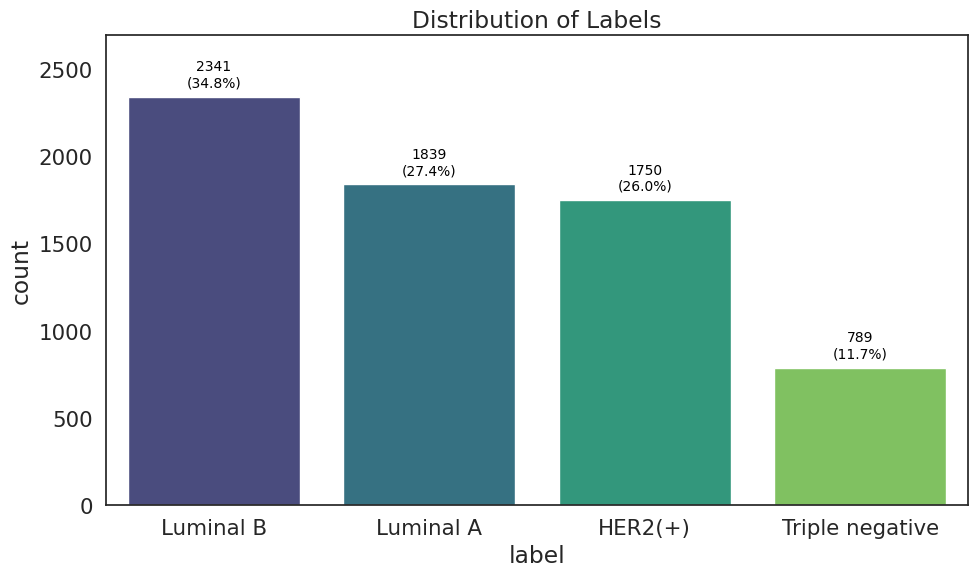

In [17]:
# --- Complete dataset ---
df_trainval_labels = pd.read_csv(trainval_labels_path)
ds_trainval = GrumpyDoctogresDataset(
    mode='train',
    data_dir=trainval_data_dir,
    labels_df=df_trainval_labels,
    transform=None,
    mean=[0,0,0], # skip for complete dataset
    std=[1,1,1]   # skip for complete dataset
)
print(f"Complete dataset size: {len(ds_trainval)}")
print("\n")


# --- Train/Val datasets ---
# - SPLIT
train_idxs, val_idxs = train_test_split(
    df_trainval_labels.index,
    test_size=VAL_SIZE,
    stratify=df_trainval_labels['label'],
    random_state=SEED
)

# - TRAIN AUGMENTATION
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5)
])
# - TRAIN SET
ds_train = GrumpyDoctogresDataset(
    mode='train',
    data_dir=trainval_data_dir,
    labels_df=df_trainval_labels,
    filter_indices=train_idxs,
    transform=train_transform
    # in Transfer Learning: specify custom 'mean' and 'std' for normalization
    # mean=(0.485, 0.456, 0.406), e.g., ImageNet mean
    # std=(0.229, 0.224, 0.225)   e.g., ImageNet std
)
train_mean = ds_train.mean.cpu().tolist()
train_std = ds_train.std.cpu().tolist()
print("\n")

# - VALIDATION SET
ds_val = GrumpyDoctogresDataset(
    mode='train',
    data_dir=trainval_data_dir,
    labels_df=df_trainval_labels,
    filter_indices=val_idxs,
    transform=None,
    mean=train_mean,
    std=train_std
)
print("\n")

print(f"Train size: {len(ds_train)} | Val size: {len(ds_val)}")


ds_trainval.plot_labels_distribution()

## 🧮 **Network Parameters**

In [18]:
# Problem parameters
input_shape = (3, 256, 256)
num_classes = 4

# Training setup
BATCH_SIZE = 32            # @param Batch size
LEARNING_RATE = 1e-3       # @param Learning rate
EPOCHS = 1000              # @param Maximum number of training epochs
PATIENCE = 100             # @param Early-stopping patience

# Training regularization setup
DROPOUT_RATE = 0.2         # @param Dropout probability
L1_LAMBDA = 0              # @param L1 penalty
L2_LAMBDA = 0              # @param L2 penalty

# Loss function setup
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Batch Size: 32
Epochs: 1000
Learning Rate: 0.001
Dropout Rate: 0.2
L1 Penalty: 0
L2 Penalty: 0


### Model setup

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 256, 256]             448
              ReLU-2         [-1, 16, 256, 256]               0
         MaxPool2d-3         [-1, 16, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           4,640
              ReLU-5         [-1, 32, 128, 128]               0
         MaxPool2d-6           [-1, 32, 64, 64]               0
            Conv2d-7           [-1, 64, 64, 64]          18,496
              ReLU-8           [-1, 64, 64, 64]               0
         MaxPool2d-9           [-1, 64, 32, 32]               0
           Conv2d-10          [-1, 128, 32, 32]          73,856
             ReLU-11          [-1, 128, 32, 32]               0
AdaptiveAvgPool2d-12            [-1, 128, 1, 1]               0
          Flatten-13                  [-1, 128]               0
          Dropout-14                  [

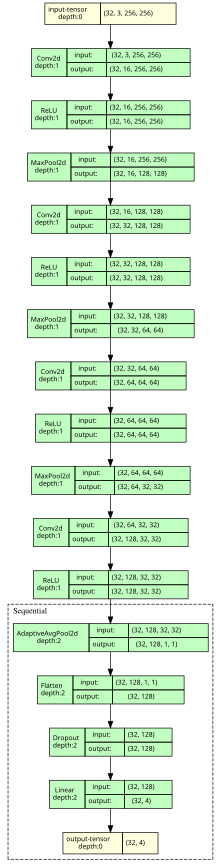

In [19]:
# Instantiate CNN model and move to computing device (CPU/GPU)
vanilla_model = SimpleCNN(
    input_shape,
    num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Display model architecture summary
summary(vanilla_model, input_size=input_shape)
model_graph = draw_graph(vanilla_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
model_graph.visual_graph

In [20]:
# Set up TensorBoard logging and save model architecture
experiment_name = "vanilla_cnn"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(vanilla_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))


# Setup Train/Val batch DataLoader
train_loader = make_loader(ds_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = make_loader(ds_val, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
# -- Debug: print loader's shape
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break  # Stop after getting one batch

Features batch shape: torch.Size([32, 3, 256, 256])
Labels batch shape: torch.Size([32])


### Run

In [21]:
%%time
# Train model and track training history
vanilla_model, vanilla_history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE
)

# Update best model if current performance is superior
if vanilla_history['val_f1'][-1] > best_performance:
    best_model = vanilla_model
    best_performance = vanilla_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(vanilla_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 1000 epochs...


Epoch   1/1000 | Train: Loss=1.3270, F1 Score=0.3383 | Val: Loss=1.3311, F1 Score=0.3430


Epoch   2/1000 | Train: Loss=1.3203, F1 Score=0.3481 | Val: Loss=1.3237, F1 Score=0.3482


Epoch   3/1000 | Train: Loss=1.3179, F1 Score=0.3486 | Val: Loss=1.3238, F1 Score=0.3482


Epoch   4/1000 | Train: Loss=1.3163, F1 Score=0.3496 | Val: Loss=1.3225, F1 Score=0.3482


...

Epoch 260/1000 | Train: Loss=0.4394, F1 Score=0.8262 | Val: Loss=1.0153, F1 Score=0.6562


Epoch 261/1000 | Train: Loss=0.4510, F1 Score=0.8213 | Val: Loss=1.0035, F1 Score=0.6496


Epoch 262/1000 | Train: Loss=0.4530, F1 Score=0.8307 | Val: Loss=1.0258, F1 Score=0.6585


Epoch 263/1000 | Train: Loss=0.4397, F1 Score=0.8254 | Val: Loss=1.0667, F1 Score=0.6525


KeyboardInterrupt: 

In [ ]:
import torch.nn.functional as F

# Set the model to evaluation mode
vanilla_model.eval()

all_preds = []
all_true = []

# No gradient calculation needed for inference
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = vanilla_model(inputs)
            probabilities = F.softmax(logits, dim=1)

        # Get predicted class (index of max probability)
        _, predicted = torch.max(probabilities, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(targets.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_true, all_preds)

# Map integer labels back to string labels for better readability
label_mapping_inv = {v: k for k, v in ds_train.label_mapping.items()}
class_names = [label_mapping_inv[i] for i in sorted(label_mapping_inv.keys())]

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Vanilla CNN on Validation Set')
plt.show()

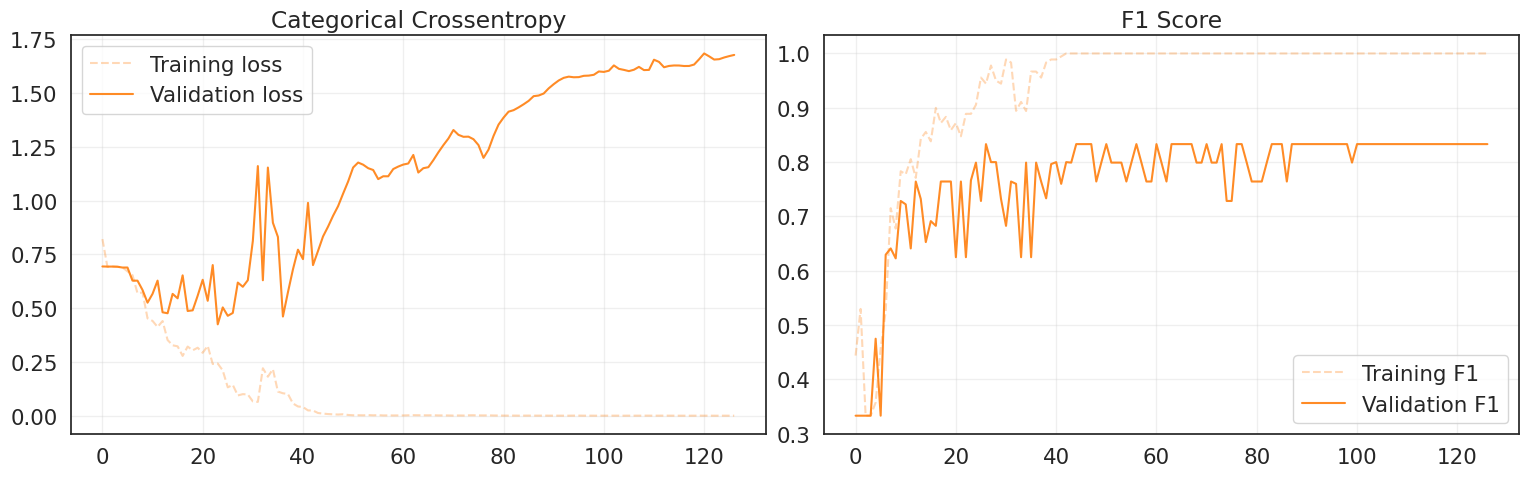

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(vanilla_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(vanilla_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation F1 score on the second axis
ax2.plot(vanilla_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(vanilla_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

---
# **Training execution**

## 📥 **Data loading**

In [27]:
# Train/Val setup
VAL_SIZE = 0.2    # @param Size or ratio for the validation set

# 224, stride 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


Provided Mean: tensor([0., 0., 0.]), Std: tensor([1., 1., 1.])
Complete dataset size: 7627


Provided Mean: tensor([0.4850, 0.4560, 0.4060]), Std: tensor([0.2290, 0.2240, 0.2250])


Provided Mean: tensor([0.4850, 0.4560, 0.4060]), Std: tensor([0.2290, 0.2240, 0.2250])


Train size: 6101 | Val size: 1526


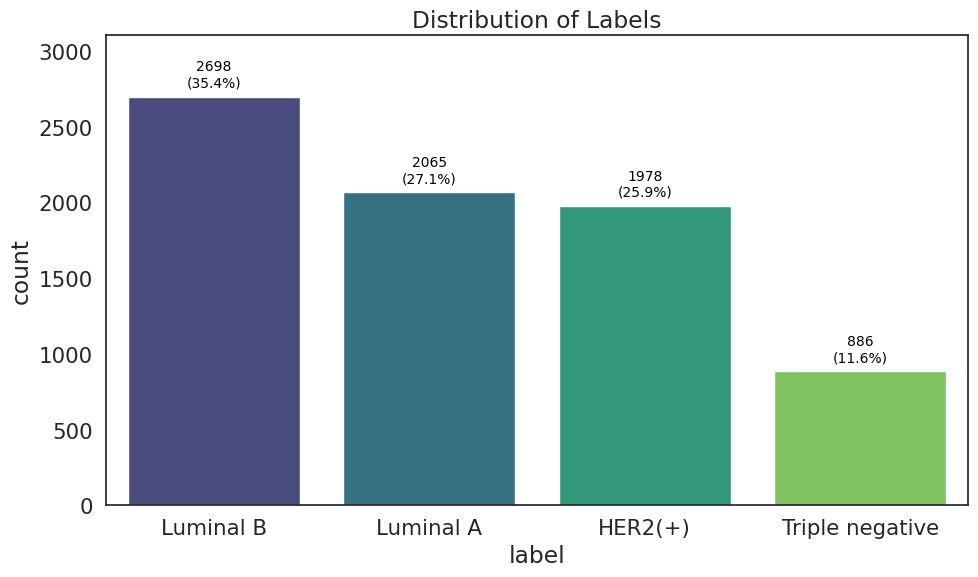

In [28]:
# --- Complete dataset ---
df_trainval_labels = pd.read_csv(trainval_labels_path)
ds_trainval = GrumpyDoctogresDataset(
    mode='train',
    data_dir=trainval_data_dir,
    labels_df=df_trainval_labels,
    transform=None,
    mean=[0,0,0], # skip for complete dataset
    std=[1,1,1]   # skip for complete dataset
)
print(f"Complete dataset size: {len(ds_trainval)}")
print("\n")


# --- Train/Val datasets ---
# - SPLIT
train_idxs, val_idxs = train_test_split(
    df_trainval_labels.index,
    test_size=VAL_SIZE,
    stratify=df_trainval_labels['label'],
    random_state=SEED
)

# - TRAIN AUGMENTATION
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5)
])
# - TRAIN SET
ds_train = GrumpyDoctogresDataset(
    mode='train',
    data_dir=trainval_data_dir,
    labels_df=df_trainval_labels,
    filter_indices=train_idxs,
    transform=train_transform,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)
train_mean = ds_train.mean.cpu().tolist()
train_std = ds_train.std.cpu().tolist()
print("\n")

# - VALIDATION SET
ds_val = GrumpyDoctogresDataset(
    mode='train',
    data_dir=trainval_data_dir,
    labels_df=df_trainval_labels,
    filter_indices=val_idxs,
    transform=None,
    mean=train_mean,
    std=train_std
)
print("\n")

print(f"Train size: {len(ds_train)} | Val size: {len(ds_val)}")


ds_trainval.plot_labels_distribution()

## 🧮 **Network Parameters**

In [44]:
# Model parameters
input_shape = (3, 224, 224)
num_classes = 4
FREEZE_BACKBONE = True     # @param Whether to freeze the FEN
NUM_FC_LAYERS = 0          # @param Number of fully-connected layers in the classifier head
FC_NEURONS    = 512        # @param Number of neurons per fully-connected layer

# Training setup
BATCH_SIZE = 32            # @param Batch size
LEARNING_RATE = 1e-3       # @param Learning rate
EPOCHS = 1000              # @param Maximum number of training epochs
PATIENCE = 50              # @param Early-stopping patience

# Training regularization setup
DROPOUT_RATE = 0.2         # @param Dropout probability
L1_LAMBDA = 0              # @param L1 penalty
L2_LAMBDA = 0              # @param L2 penalty

# Loss function setup
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Batch Size: 32
Epochs: 1000
Learning Rate: 0.001
Dropout Rate: 0.2
L1 Penalty: 0
L2 Penalty: 0


### Model setup

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

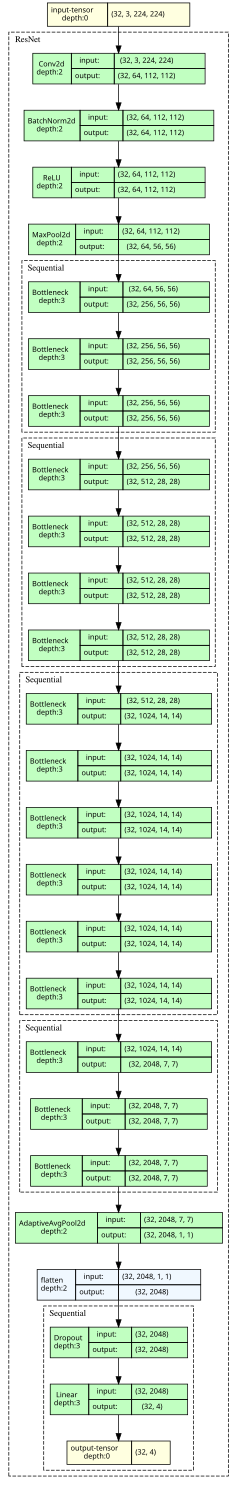

In [45]:
# Instantiate CNN model and move to computing device (CPU/GPU)
resnet_model = ResNet50Model(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    freeze_backbone=FREEZE_BACKBONE,
    num_fc_layers=NUM_FC_LAYERS,
    fc_neurons=FC_NEURONS
).to(device)

# Display model architecture summary
summary(resnet_model, input_size=input_shape)
model_graph = draw_graph(resnet_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
model_graph.visual_graph

In [46]:
# Set up TensorBoard logging and save model architecture
experiment_name = "resnet50_cnn_v0-independent-patches"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(vanilla_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))


# Setup Train/Val batch DataLoader
train_loader = make_loader(ds_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = make_loader(ds_val, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
# -- Debug: print loader's shape
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break  # Stop after getting one batch

Features batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


### Run

In [47]:
%%time
# Train model and track training history
resnet_model, resnet_history = fit(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE
)

# Update best model if current performance is superior
if resnet_history['val_f1'][-1] > best_performance:
    best_model = resnet_model
    best_performance = resnet_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(resnet_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 1000 epochs...


Epoch   1/1000 | Train: Loss=1.3161, F1 Score=0.3549 | Val: Loss=1.3062, F1 Score=0.3637


Epoch   2/1000 | Train: Loss=1.2785, F1 Score=0.3918 | Val: Loss=1.2960, F1 Score=0.3860


Epoch   3/1000 | Train: Loss=1.2588, F1 Score=0.4084 | Val: Loss=1.2786, F1 Score=0.3755


Epoch   4/1000 | Train: Loss=1.2431, F1 Score=0.4133 | Val: Loss=1.2786, F1 Score=0.3958


...

Epoch  91/1000 | Train: Loss=1.1721, F1 Score=0.4694 | Val: Loss=1.2485, F1 Score=0.4358


Epoch  92/1000 | Train: Loss=1.1650, F1 Score=0.4696 | Val: Loss=1.2700, F1 Score=0.4240


Epoch  93/1000 | Train: Loss=1.1714, F1 Score=0.4613 | Val: Loss=1.2599, F1 Score=0.4220


Epoch  94/1000 | Train: Loss=1.1672, F1 Score=0.4730 | Val: Loss=1.2884, F1 Score=0.4142


Epoch  95/1000 | Train: Loss=1.1721, F1 Score=0.4577 | Val: Loss=1.2689, F1 Score=0.4318
Early stopping triggered after 95 epochs.
Best model restored from epoch 45 with val_f1 0.4495
Final validation F1 score: 44.95%
CPU times: user 16min 7s, sys: 2min 28s, total: 18min 35s
Wall time: 41min 57s


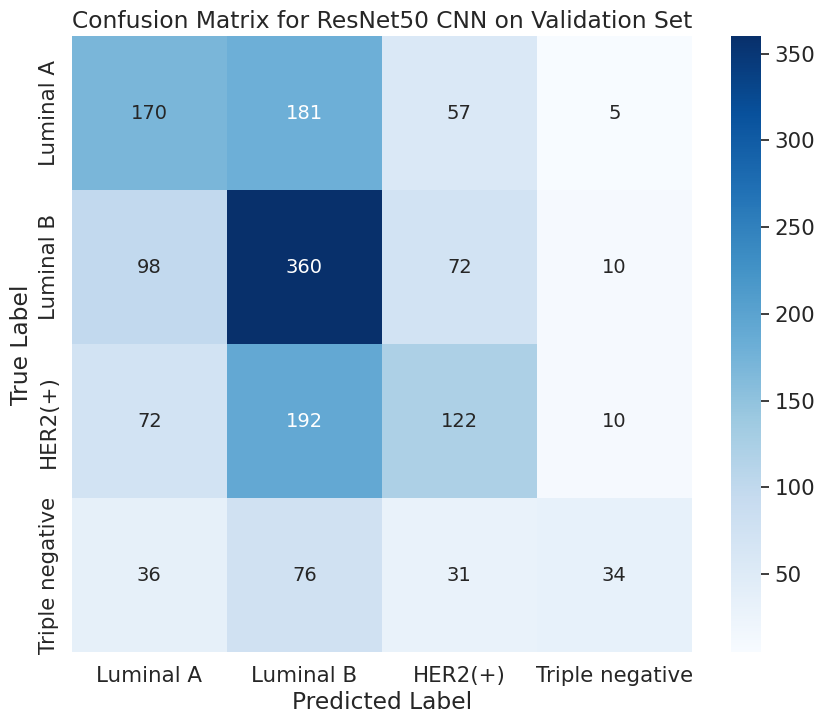

In [48]:
import torch.nn.functional as F

# Set the model to evaluation mode
resnet_model.eval()

all_preds = []
all_true = []

# No gradient calculation needed for inference
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = resnet_model(inputs)
            probabilities = F.softmax(logits, dim=1)

        # Get predicted class (index of max probability)
        _, predicted = torch.max(probabilities, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(targets.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_true, all_preds)

# Map integer labels back to string labels for better readability
label_mapping_inv = {v: k for k, v in ds_train.label_mapping.items()}
class_names = [label_mapping_inv[i] for i in sorted(label_mapping_inv.keys())]

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ResNet50 CNN on Validation Set')
plt.show()

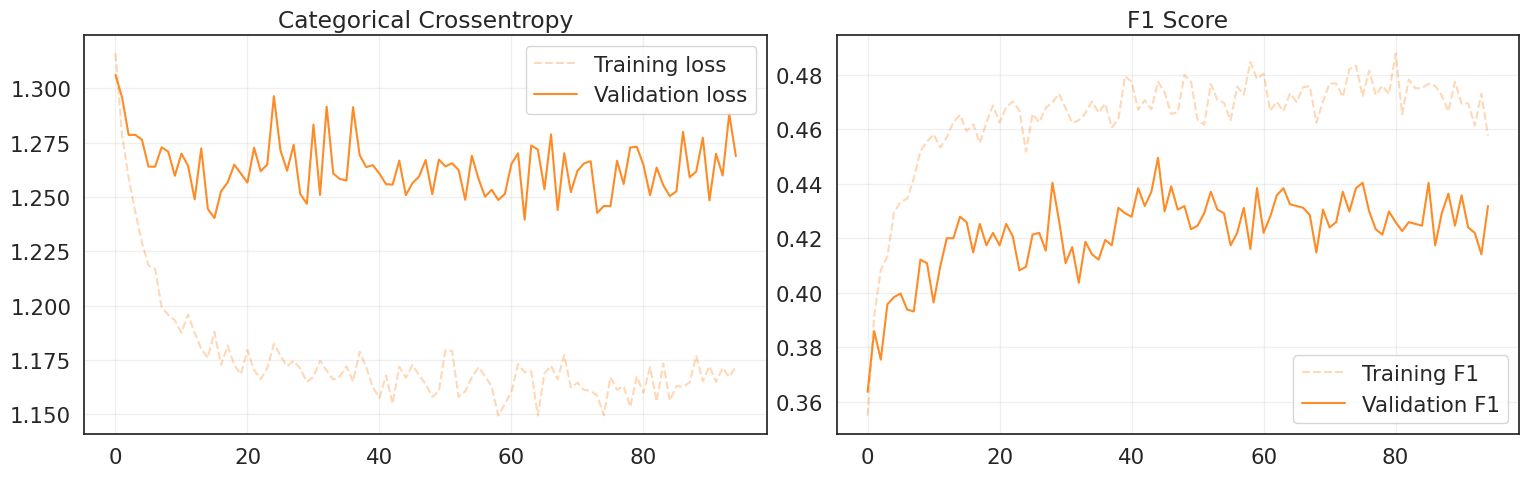

In [49]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(resnet_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(resnet_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation F1 score on the second axis
ax2.plot(resnet_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(resnet_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

---
# **Inference execution**

## 🧮 **Parameters**

In [50]:
NORM_MEAN = ds_train.mean.cpu().tolist()  # Normalization mean used in training
NORM_STD = ds_train.std.cpu().tolist()    # Normalization std used in training

PATCH_MASK_THRESHOLD = 0.05   # @param Mask threshold to make a patch valid for inference
PATCH_SIZE = 224              # @param Patch size
PATCH_STRIDE = 56             # @param Patch stride

## 🔮 **Run**

In [58]:
# --- Test dataset ---
final_model = best_model if best_model is not None else vanilla_model

ds_test = GrumpyDoctogresDataset(
    mode='test',
    data_dir=test_data_dir,
    transform=None,
    mean=NORM_MEAN,
    std=NORM_STD
)
print(f"Test size: {len(ds_test)}")
print("\n")

df = run_production_inference(
    model=final_model,
    test_dataset=ds_test,
    output_csv=f"{experiment_name}_submission.csv",
    device=device,
    patch_mask_threshold=PATCH_MASK_THRESHOLD,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE
)

Test size: 954


Starting inference on 954 samples...
Tiling Config -> Size: 224, Stride: 56
Mask Config -> Threshold: 0.05


100%|██████████| 954/954 [04:10<00:00,  3.81it/s]




Inference Complete. Saved 954 rows to resnet50_cnn_v0-independent-patches_submission.csv

--- Label Distribution Summary ---
label
Luminal B          719
Luminal A          132
HER2(+)            102
Triple negative      1
Name: count, dtype: int64
